# Newline metrics after separately ablating every attention head

For each attention head, this notebook replaces that head's `hook_z` output at every batch and sequence position with either its global mean over a separate calibration sample or zero, controlled by `ABLATION_TYPE`. It then evaluates that one-head ablation on the same fixed evaluation sample.

The displayed newline metrics are:

- **Accuracy on true newlines (recall):** among positions whose target is `_NEWLINE_`, the fraction predicted as `_NEWLINE_`.
- **Accuracy when predicting newlines (precision):** among positions predicted as `_NEWLINE_`, the fraction whose target is `_NEWLINE_`.
- **Newline prediction frequency:** the fraction of all evaluated positions predicted as `_NEWLINE_`.

An unablated baseline is included, and all single-head ablations share the same evaluation examples.

In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import project_main.checkpoints as project_checkpoints
import project_main.data as project_data
import project_main.model as project_model
import project_main.tokens as project_tokens

RUN_DIR = Path("../results/line_breaks_results")
CHECKPOINT_PATH = RUN_DIR / "checkpoints" / "final.pt"

# Toggle between "mean" and "zero" ablation.
ABLATION_TYPE = "mean"

N_MEAN_SEQUENCES = 2_048
N_EVAL_SEQUENCES = 1_024
BATCH_SIZE = 128
MEAN_DATA_SEED = 13_001
EVAL_DATA_SEED = 13_002

In [2]:
with open(RUN_DIR / "config.json", "r") as f:
    cfg = json.load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"
vocab = project_tokens.build_vocab(cfg["task"])
model = project_model.build_model(cfg=cfg, device=device)
checkpoint = project_checkpoints.load_checkpoint(
    path=CHECKPOINT_PATH,
    model=model,
    map_location=device,
)
model.eval()

n_layers = cfg["model"]["n_layers"]
n_heads = cfg["model"]["n_heads"]
d_head = cfg["model"]["d_head"]
z_names = [f"blocks.{layer}.attn.hook_z" for layer in range(n_layers)]

if ABLATION_TYPE not in {"mean", "zero"}:
    raise ValueError("ABLATION_TYPE must be either 'mean' or 'zero'.")

print(f"Loaded checkpoint step {checkpoint['step']} on {device}")
print(f"Model: {n_layers} layers x {n_heads} heads")
print(f"Ablation type: {ABLATION_TYPE}")
if ABLATION_TYPE == "mean":
    print(f"Calibration sequences: {N_MEAN_SEQUENCES:,}")
print(f"Evaluation sequences: {N_EVAL_SEQUENCES:,}")

Building vocab...
('BOS', '_NEWLINE_')
Loaded checkpoint step 10000 on cpu
Model: 3 layers x 4 heads
Ablation type: mean
Calibration sequences: 2,048
Evaluation sequences: 1,024


## Construct the replacement vectors

With mean ablation, each layer/head replacement is its calibration mean over all sequence positions and examples; the calibration and evaluation seeds are distinct. With zero ablation, calibration is skipped and every replacement vector is zero.

In [3]:
@torch.no_grad()
def estimate_all_head_means(
    n_sequences: int,
    *,
    batch_size: int = BATCH_SIZE,
    seed: int = MEAN_DATA_SEED,
) -> torch.Tensor:
    """Estimate E[z] for every [layer, head] over examples and positions."""
    head_sums = torch.zeros(
        n_layers, n_heads, d_head, dtype=torch.float64
    )
    n_vectors = 0

    for start in range(0, n_sequences, batch_size):
        this_batch_size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size,
            vocab=vocab,
            task_cfg=cfg["task"],
            device=device,
            seed=seed + start,
        )
        _, cache = model.run_with_cache(
            batch.tokens,
            prepend_bos=False,
            names_filter=lambda name: name in z_names,
        )
        for layer, z_name in enumerate(z_names):
            # z: [batch, position, head, d_head]
            head_sums[layer] += (
                cache[z_name].detach().cpu().double().sum(dim=(0, 1))
            )
        n_vectors += this_batch_size * cfg["task"]["seq_len"]

    if n_vectors == 0:
        raise RuntimeError("No calibration activations were collected.")
    return (head_sums / n_vectors).float()


if ABLATION_TYPE == "mean":
    replacement_head_outputs = estimate_all_head_means(N_MEAN_SEQUENCES)
else:
    replacement_head_outputs = torch.zeros(n_layers, n_heads, d_head)

assert replacement_head_outputs.shape == (n_layers, n_heads, d_head)
print("Replacement tensor:", tuple(replacement_head_outputs.shape))
print("Replacement-vector norms by layer/head:")
display(pd.DataFrame(replacement_head_outputs.norm(dim=-1).numpy()))

Replacement tensor: (3, 4, 32)
Replacement-vector norms by layer/head:


,0,1,2,3
0,1.920199,5.413742,5.347842,4.556371
1,2.504408,3.977080,3.142638,3.217443
2,3.119715,7.922318,2.825696,5.061132


## Evaluate the baseline and every single-head ablation

Counts are accumulated over the complete evaluation set, so the reported quantities are dataset-level recall and precision rather than averages of per-batch ratios. Precision is reported as `NaN` if an ablation never predicts a newline.

In [4]:
@torch.no_grad()
def evaluate_newline_metrics(
    ablate_layer: int | None = None,
    ablate_head: int | None = None,
    *,
    n_sequences: int = N_EVAL_SEQUENCES,
    batch_size: int = BATCH_SIZE,
    seed: int = EVAL_DATA_SEED,
) -> dict[str, float | int]:
    if (ablate_layer is None) != (ablate_head is None):
        raise ValueError("Set both ablate_layer and ablate_head, or neither.")

    true_positives = 0
    actual_newlines = 0
    predicted_newlines = 0
    total_positions = 0

    fwd_hooks = []
    if ablate_layer is not None:
        replacement = replacement_head_outputs[ablate_layer, ablate_head]

        def ablate_selected_head(z, hook):
            ablated = z.clone()
            ablated[:, :, ablate_head, :] = replacement.to(
                device=z.device, dtype=z.dtype
            )
            return ablated

        fwd_hooks = [(z_names[ablate_layer], ablate_selected_head)]

    for start in range(0, n_sequences, batch_size):
        this_batch_size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(
            batch_size=this_batch_size,
            vocab=vocab,
            task_cfg=cfg["task"],
            device=device,
            seed=seed + start,
        )
        logits = model.run_with_hooks(
            batch.tokens,
            prepend_bos=False,
            fwd_hooks=fwd_hooks,
        )
        predictions = logits.argmax(dim=-1)
        target_is_newline = batch.targets == vocab.newline_id
        prediction_is_newline = predictions == vocab.newline_id

        true_positives += (
            target_is_newline & prediction_is_newline
        ).sum().item()
        actual_newlines += target_is_newline.sum().item()
        predicted_newlines += prediction_is_newline.sum().item()
        total_positions += predictions.numel()

    recall = true_positives / actual_newlines if actual_newlines else np.nan
    precision = (
        true_positives / predicted_newlines if predicted_newlines else np.nan
    )
    prediction_frequency = predicted_newlines / total_positions
    return {
        "newline_recall": recall,
        "newline_precision": precision,
        "newline_prediction_frequency": prediction_frequency,
        "true_positive_newlines": true_positives,
        "actual_newlines": actual_newlines,
        "predicted_newlines": predicted_newlines,
    }


baseline = evaluate_newline_metrics()
records = []
for layer in range(n_layers):
    for head in range(n_heads):
        metrics = evaluate_newline_metrics(layer, head)
        records.append({"layer": layer, "head": head, **metrics})
        print(
            f"L{layer}H{head}: recall={metrics['newline_recall']:.4f}, "
            f"precision={metrics['newline_precision']:.4f}, "
            f"frequency={metrics['newline_prediction_frequency']:.4f}"
        )

results = pd.DataFrame.from_records(records)
results["recall_change"] = (
    results["newline_recall"] - baseline["newline_recall"]
)
results["precision_change"] = (
    results["newline_precision"] - baseline["newline_precision"]
)

print("Baseline:", baseline)

L0H0: recall=1.0000, precision=0.0625, frequency=0.8537


L0H1: recall=0.2618, precision=0.2084, frequency=0.0671


L0H2: recall=0.8064, precision=0.5465, frequency=0.0788


L0H3: recall=0.1744, precision=0.2309, frequency=0.0403


L1H0: recall=0.8979, precision=0.4639, frequency=0.1033


...

L1H3: recall=0.5115, precision=0.4007, frequency=0.0682


L2H0: recall=0.9978, precision=0.5053, frequency=0.1054


L2H1: recall=0.9999, precision=0.4042, frequency=0.1321


L2H2: recall=0.9344, precision=0.4926, frequency=0.1013


L2H3: recall=0.7439, precision=0.4818, frequency=0.0824
Baseline: {'newline_recall': 0.9997561273015486, 'newline_precision': 0.5185302302049076, 'newline_prediction_frequency': 0.10294270833333333, 'true_positive_newlines': 8199, 'actual_newlines': 8201, 'predicted_newlines': 15812}


## Results table

Each row is one independent intervention; no two heads are ablated together. Changes are in absolute accuracy units relative to the unablated baseline.

In [5]:
display_columns = [
    "layer",
    "head",
    "newline_recall",
    "newline_precision",
    "newline_prediction_frequency",
    "recall_change",
    "precision_change",
    "actual_newlines",
    "predicted_newlines",
]

print(
    f"Unablated baseline — recall: {baseline['newline_recall']:.4f}; "
    f"precision: {baseline['newline_precision']:.4f}; "
    f"prediction frequency: {baseline['newline_prediction_frequency']:.4f}; "
    f"actual/predicted newlines: {baseline['actual_newlines']:,}/"
    f"{baseline['predicted_newlines']:,}"
)
display(
    results[display_columns].style
    .format({
        "newline_recall": "{:.4f}",
        "newline_precision": "{:.4f}",
        "newline_prediction_frequency": "{:.4f}",
        "recall_change": "{:+.4f}",
        "precision_change": "{:+.4f}",
    })
    .background_gradient(
        subset=["recall_change", "precision_change"],
        cmap="RdBu",
        vmin=-max(
            results[["recall_change", "precision_change"]].abs().max()
        ),
        vmax=max(
            results[["recall_change", "precision_change"]].abs().max()
        ),
    )
)

Unablated baseline — recall: 0.9998; precision: 0.5185; prediction frequency: 0.1029; actual/predicted newlines: 8,201/15,812


,layer,head,newline_recall,newline_precision,newline_prediction_frequency,recall_change,precision_change,actual_newlines,predicted_newlines
0,0,0,1.0000,0.0625,0.8537,+0.0002,-0.4560,8201,131129
1,0,1,0.2618,0.2084,0.0671,-0.7380,-0.3101,8201,10302
2,0,2,0.8064,0.5465,0.0788,-0.1934,+0.0280,8201,12101
3,0,3,0.1744,0.2309,0.0403,-0.8254,-0.2876,8201,6193
4,1,0,0.8979,0.4639,0.1033,-0.1018,-0.0546,8201,15873
5,1,1,0.0000,0.0000,0.0123,-0.9998,-0.5185,8201,1888
6,1,2,0.9768,0.5121,0.1018,-0.0229,-0.0064,8201,15643
7,1,3,0.5115,0.4007,0.0682,-0.4882,-0.1178,8201,10469
8,2,0,0.9978,0.5053,0.1054,-0.0020,-0.0133,8201,16195
9,2,1,0.9999,0.4042,0.1321,+0.0001,-0.1144,8201,20289


## Heatmaps by layer and head

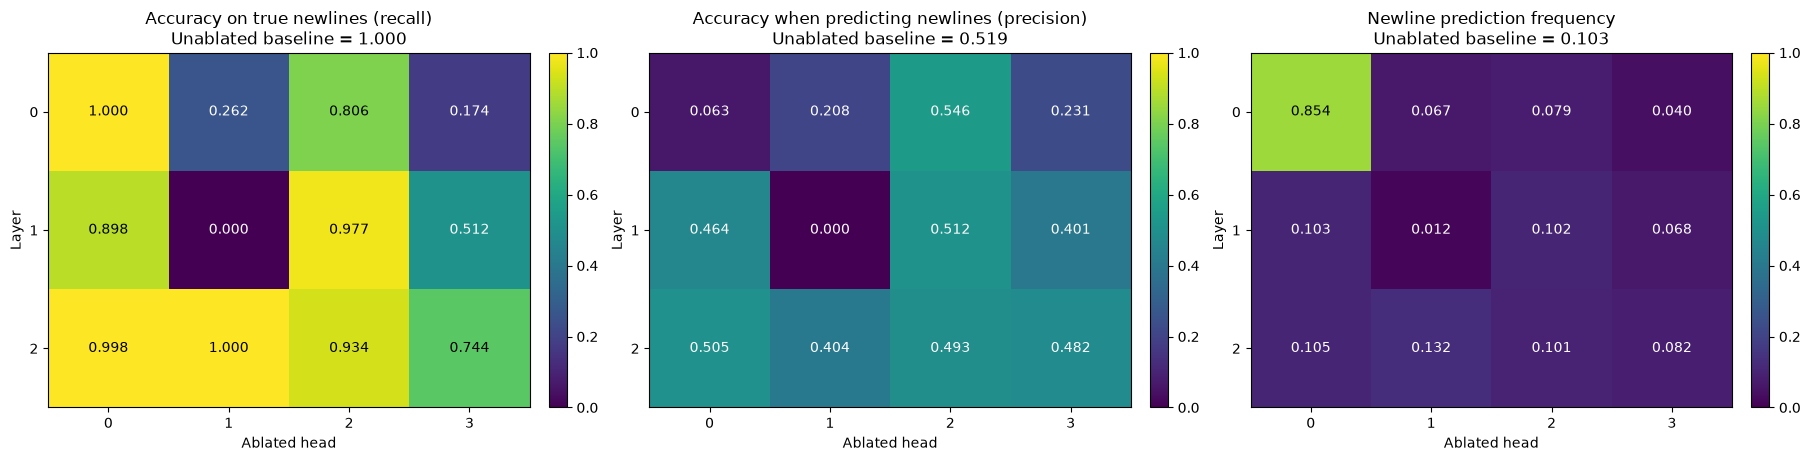

In [6]:
recall_matrix = results.pivot(
    index="layer", columns="head", values="newline_recall"
).to_numpy()
precision_matrix = results.pivot(
    index="layer", columns="head", values="newline_precision"
).to_numpy()
frequency_matrix = results.pivot(
    index="layer", columns="head", values="newline_prediction_frequency"
).to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), constrained_layout=True)
plots = [
    (recall_matrix, "Accuracy on true newlines (recall)", baseline["newline_recall"]),
    (precision_matrix, "Accuracy when predicting newlines (precision)", baseline["newline_precision"]),
    (frequency_matrix, "Newline prediction frequency", baseline["newline_prediction_frequency"]),
]

for ax, (matrix, title, baseline_value) in zip(axes, plots):
    image = ax.imshow(matrix, cmap="viridis", vmin=0.0, vmax=1.0, aspect="auto")
    for layer in range(n_layers):
        for head in range(n_heads):
            value = matrix[layer, head]
            text_color = "white" if value < 0.55 else "black"
            ax.text(head, layer, f"{value:.3f}", ha="center", va="center", color=text_color)
    ax.set_xticks(range(n_heads), labels=range(n_heads))
    ax.set_yticks(range(n_layers), labels=range(n_layers))
    ax.set_xlabel("Ablated head")
    ax.set_ylabel("Layer")
    ax.set_title(f"{title}\nUnablated baseline = {baseline_value:.3f}")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

plt.show()